1. Use the inbuilt dataset 'titanic'. The dataset contains 891 rows and contains information about the passengers who boarded the unfortunate Titanic ship. Use the Seaborn library to see if we can find any patterns in the data.
2. Write a code to check how the price of the ticket (column name: 'fare') for each passenger is distributed by plotting a histogram.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.options.display.max_columns = None
sns.set(style='whitegrid', palette='Set2')

In [2]:
# Load dataset
titanic = sns.load_dataset('titanic')
print('Dataset loaded successfully')
titanic.head()

Dataset loaded successfully


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# EDA:
print('Shape:', titanic.shape)
print('Size:', titanic.size)

Shape: (891, 15)
Size: 13365


In [4]:
print('\nInfo:')
titanic.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
print('\nDescribe (numeric columns):')
titanic.describe()


Describe (numeric columns):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print('\nCategorical columns summary:')
print('Unique values per column:')
print(titanic.nunique())


Categorical columns summary:
Unique values per column:
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


In [7]:
print('\nSurvival distribution:')
print(titanic['survived'].value_counts())
print('\nClass distribution:')
print(titanic['pclass'].value_counts())
print('\nSex distribution:')
print(titanic['sex'].value_counts())


Survival distribution:
survived
0    549
1    342
Name: count, dtype: int64

Class distribution:
pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex distribution:
sex
male      577
female    314
Name: count, dtype: int64


In [8]:
print('\nNull counts before removal:')
print(titanic.isnull().sum())


Null counts before removal:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
# Remove null values
titanic_clean = titanic.dropna(subset=['survived', 'age', 'fare', 'embarked', 'embark_town']).reset_index(drop=True)
print('Shape after cleanup:', titanic_clean.shape)
print('Null counts after cleanup (key columns):\n', titanic_clean[['survived', 'age', 'fare']].isnull().sum(), sep="")

Shape after cleanup: (712, 15)
Null counts after cleanup (key columns):
survived    0
age         0
fare        0
dtype: int64


In [10]:
titanic_clean.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           530
embark_town      0
alive            0
alone            0
dtype: int64

C:\Users\ADITI SANT\AppData\Local\Temp\ipykernel_6296\2881918582.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic_clean, x='survived', palette='Set2')
C:\Users\ADITI SANT\AppData\Local\Temp\ipykernel_6296\2881918582.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic_clean, x='pclass', palette='Set2')
C:\Users\ADITI SANT\AppData\Local\Temp\ipykernel_6296\2881918582.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic_clean, x='sex', palette='Set2')


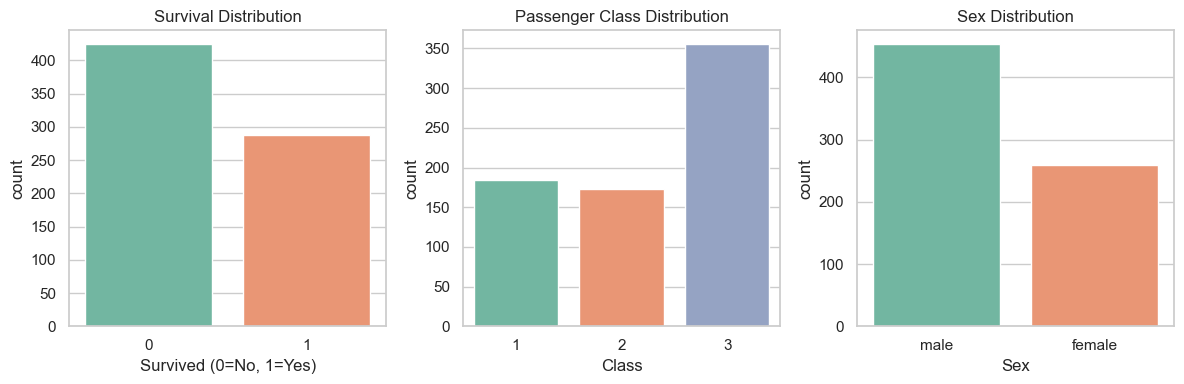

In [11]:
# Visualizations: distributions and relationships
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(data=titanic_clean, x='survived', palette='Set2')
plt.title('Survival Distribution')
plt.xlabel('Survived (0=No, 1=Yes)')

plt.subplot(1, 3, 2)
sns.countplot(data=titanic_clean, x='pclass', palette='Set2')
plt.title('Passenger Class Distribution')
plt.xlabel('Class')

plt.subplot(1, 3, 3)
sns.countplot(data=titanic_clean, x='sex', palette='Set2')
plt.title('Sex Distribution')
plt.xlabel('Sex')

plt.tight_layout()
plt.show()

Shape before outlier cleanup: (712, 15)


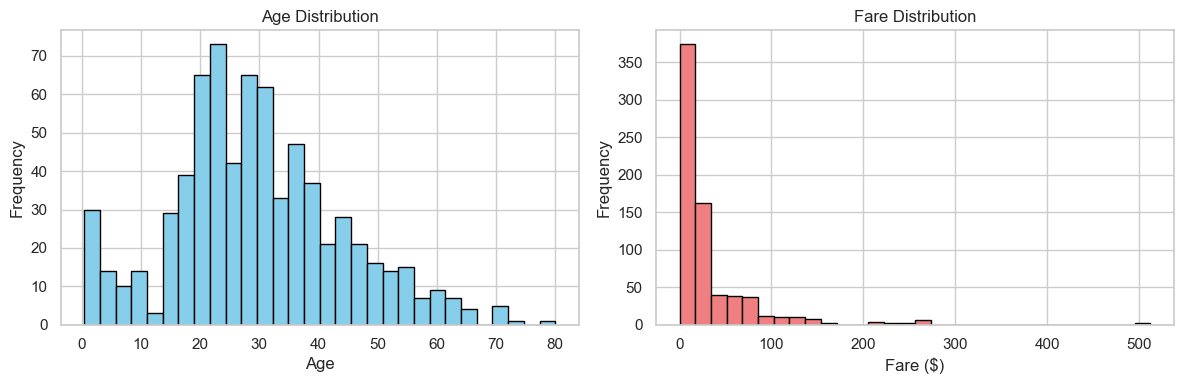

In [12]:
# Age and Fare distributions
print('Shape before outlier cleanup:', titanic_clean.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(titanic_clean['age'], bins=30, edgecolor='black', color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(titanic_clean['fare'], bins=30, edgecolor='black', color='lightcoral')
plt.title('Fare Distribution')
plt.xlabel('Fare ($)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Shape after outlier cleanup: (610, 15)


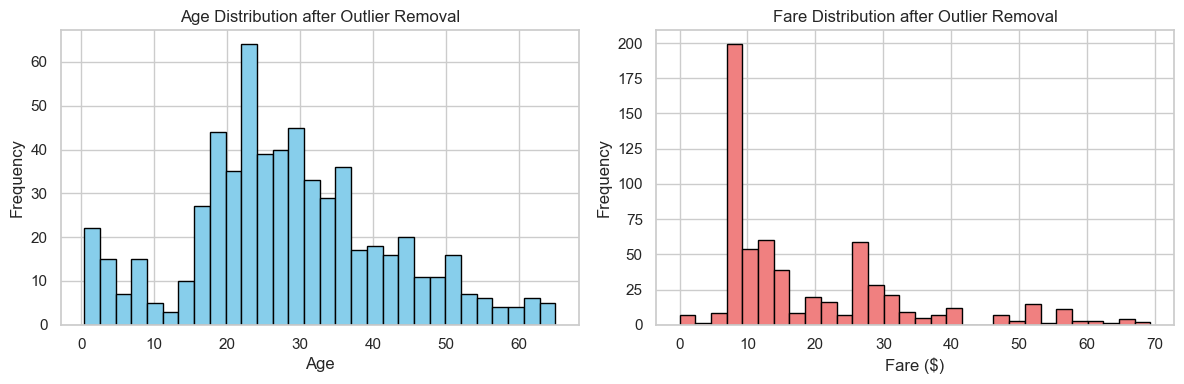

In [13]:
# Outlier detection and removal using IQR
titanic_final = titanic_clean.copy()

# Age outliers
q1_age = titanic_final['age'].quantile(0.25)
q3_age = titanic_final['age'].quantile(0.75)
iqr_age = q3_age - q1_age
lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

# Fare outliers
q1_fare = titanic_final['fare'].quantile(0.25)
q3_fare = titanic_final['fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
lower_fare = q1_fare - 1.5 * iqr_fare
upper_fare = q3_fare + 1.5 * iqr_fare

titanic_final = titanic_final[(titanic_final['age'] >= lower_age) & (titanic_final['age'] <= upper_age)]
titanic_final = titanic_final[(titanic_final['fare'] >= lower_fare) & (titanic_final['fare'] <= upper_fare)]

print('Shape after outlier cleanup:', titanic_final.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(titanic_final['age'], bins=30, edgecolor='black', color='skyblue')
plt.title('Age Distribution after Outlier Removal')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(titanic_final['fare'], bins=30, edgecolor='black', color='lightcoral')
plt.title('Fare Distribution after Outlier Removal')
plt.xlabel('Fare ($)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
# Category checks and conversion to numeric
le_sex = LabelEncoder()
titanic_final['sex_num'] = le_sex.fit_transform(titanic_final['sex'])
print('Sex mapping:', dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

le_class = LabelEncoder()
titanic_final['class_num'] = le_class.fit_transform(titanic_final['pclass'].astype(str))
print('Class mapping:', dict(zip(le_class.classes_, le_class.transform(le_class.classes_))))

titanic_final.head()

Sex mapping: {'female': np.int64(0), 'male': np.int64(1)}
Class mapping: {'1': np.int64(0), '2': np.int64(1), '3': np.int64(2)}


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_num,class_num
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0,2
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,2
5,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,1,0


TASK 1: Finding patterns in Titanic data


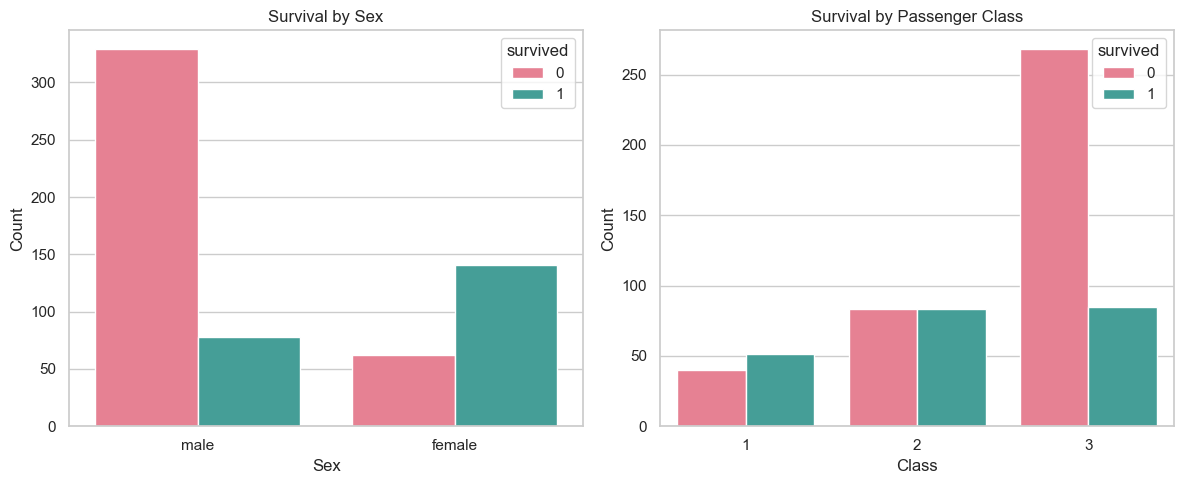


Survival Rate by Sex:
        sum  count      mean
sex                         
female  141    203  0.694581
male     78    407  0.191646

Survival Rate by Class:
        sum  count      mean
pclass                      
1        51     91  0.560440
2        83    166  0.500000
3        85    353  0.240793


In [15]:
# Task 1: Find patterns in the data using Seaborn
print('TASK 1: Finding patterns in Titanic data')

# Survival by Sex
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=titanic_final, x='sex', hue='survived', palette='husl')
plt.title('Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

# Survival by Class
plt.subplot(1, 2, 2)
sns.countplot(data=titanic_final, x='pclass', hue='survived', palette='husl')
plt.title('Survival by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Survival rate by Sex and Class
print('\nSurvival Rate by Sex:')
print(titanic_final.groupby('sex')['survived'].agg(['sum', 'count', 'mean']))

print('\nSurvival Rate by Class:')
print(titanic_final.groupby('pclass')['survived'].agg(['sum', 'count', 'mean']))

C:\Users\ADITI SANT\AppData\Local\Temp\ipykernel_6296\560809235.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic_final, x='survived', y='age', palette='Set2')
C:\Users\ADITI SANT\AppData\Local\Temp\ipykernel_6296\560809235.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic_final, x='survived', y='fare', palette='Set2')


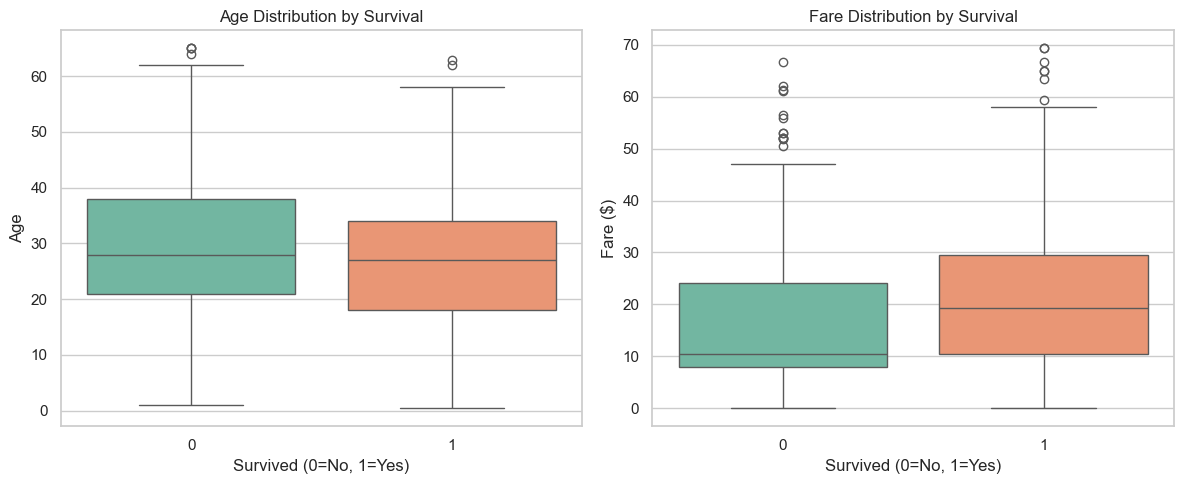


Correlation with Survival:
survived    1.000000
fare        0.238268
parch       0.095204
sibsp      -0.028801
age        -0.129342
pclass     -0.278442
Name: survived, dtype: float64


In [16]:
# Age vs Survival, Fare vs Survival
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=titanic_final, x='survived', y='age', palette='Set2')
plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(data=titanic_final, x='survived', y='fare', palette='Set2')
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Fare ($)')

plt.tight_layout()
plt.show()

# Correlation with survival
numeric_cols = ['age', 'fare', 'pclass', 'sibsp', 'parch']
correlations = titanic_final[numeric_cols + ['survived']].corr()['survived'].sort_values(ascending=False)
print('\nCorrelation with Survival:')
print(correlations)

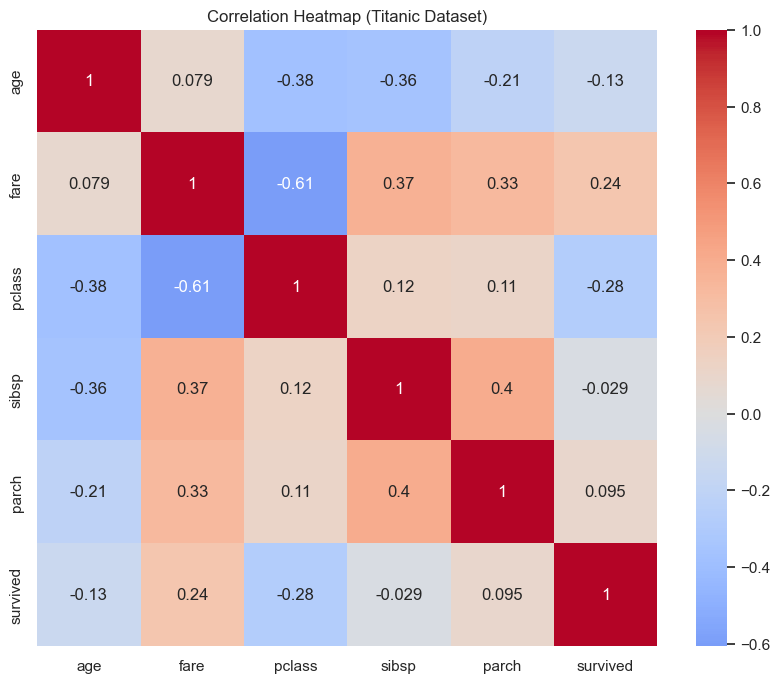

In [17]:
# Heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(titanic_final[numeric_cols + ['survived']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Titanic Dataset)')
plt.show()

TASK 2: Fare Price Distribution


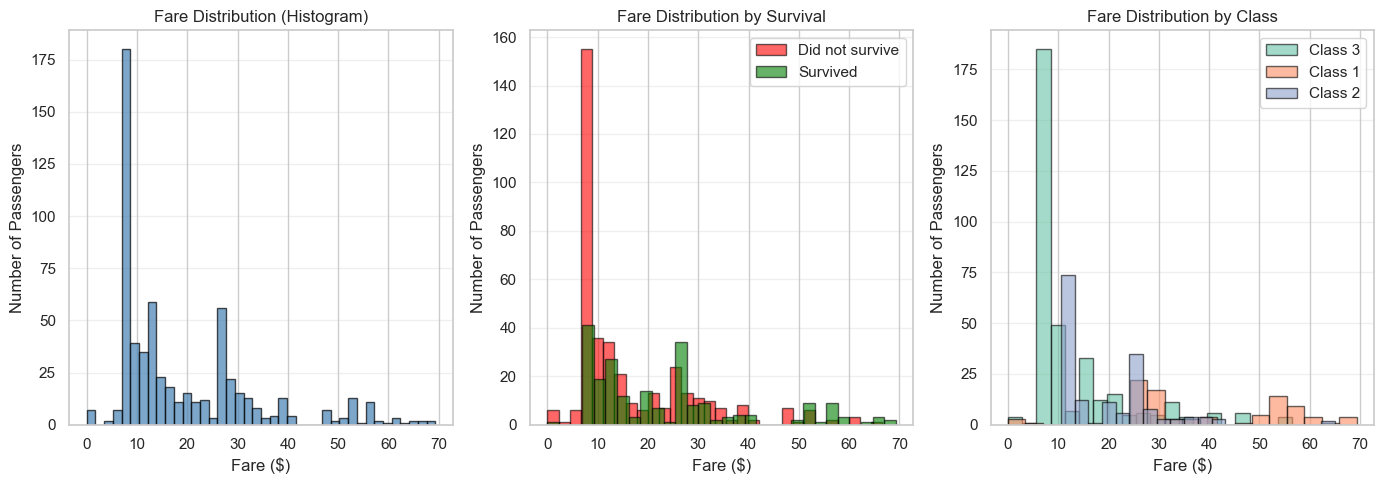


Fare by Class:
        count       mean        std   min     25%      50%      75%      max
pclass                                                                      
1        91.0  39.360991  15.980625   0.0  26.550  34.0208  53.1000  69.3000
2       166.0  20.036622   9.783995  10.5  13.000  14.7500  26.0000  65.0000
3       353.0  13.260409  10.063168   0.0   7.775   8.0500  15.7417  56.4958


In [18]:
# Task 2: Fare distribution histogram
print('TASK 2: Fare Price Distribution')

plt.figure(figsize=(14, 5))

# Histogram 1: Basic fare distribution
plt.subplot(1, 3, 1)
plt.hist(titanic_final['fare'], bins=40, edgecolor='black', color='steelblue', alpha=0.7)
plt.title('Fare Distribution (Histogram)')
plt.xlabel('Fare ($)')
plt.ylabel('Number of Passengers')
plt.grid(axis='y', alpha=0.3)

# Histogram 2: Fare by Survival
plt.subplot(1, 3, 2)
survived = titanic_final[titanic_final['survived'] == 1]['fare']
not_survived = titanic_final[titanic_final['survived'] == 0]['fare']
plt.hist(not_survived, bins=30, alpha=0.6, label='Did not survive', color='red', edgecolor='black')
plt.hist(survived, bins=30, alpha=0.6, label='Survived', color='green', edgecolor='black')
plt.title('Fare Distribution by Survival')
plt.xlabel('Fare ($)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Histogram 3: Fare by Class
plt.subplot(1, 3, 3)
for pclass in titanic_final['pclass'].unique():
    class_data = titanic_final[titanic_final['pclass'] == pclass]['fare']
    plt.hist(class_data, bins=20, alpha=0.6, label=f'Class {int(pclass)}', edgecolor='black')
plt.title('Fare Distribution by Class')
plt.xlabel('Fare ($)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Fare statistics
print('\nFare by Class:')
print(titanic_final.groupby('pclass')['fare'].describe())